# LightFracNet v3 - Bone Fracture Detection
**Dataset:** MURA v1.1 · XR_WRIST + XR_FOREARM | **Backbone:** DenseNet121 + CBAM + Grad-CAM



## 1. Setup

In [1]:
import os, random, gc, shutil, subprocess
subprocess.run(['pip', 'install', '-q', 'opencv-python-headless'], check=True)

import numpy as np
import tensorflow as tf
import keras
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    roc_curve, auc)
import json

# ── Paths ──────────────────────────────────────────────────────────────
MURA_DIR    = '/kaggle/input/datasets/cjinny/mura-v11'
WORK_DIR    = '/kaggle/working'
MODEL_DIR   = os.path.join(WORK_DIR, 'models')
RESULTS_DIR = os.path.join(WORK_DIR, 'results')
CACHE_DIR   = os.path.join(WORK_DIR, 'cache')
for d in [MODEL_DIR, RESULTS_DIR, CACHE_DIR]:
    os.makedirs(d, exist_ok=True)

CHECKPOINT_PATH = os.path.join(MODEL_DIR, 'best_model_v4.keras')
CSV_LOG_PATH    = os.path.join(MODEL_DIR, 'training_log_v4.csv')

# ── GPU + Mixed Precision ──────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU: {gpus[0].name}')
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
else:
    print('WARNING: No GPU found')

# ── Hyperparameters ────────────────────────────────────────────────────
SEED         = 42
BATCH_SIZE   = 16
IMG_SIZE     = 224
TOTAL_EPOCHS = 50
INITIAL_LR   = 2e-4
MIN_LR       = 1e-7
BODY_PARTS   = ['XR_WRIST', 'XR_FOREARM']

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('Setup complete')

2026-04-13 11:18:00.319752: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776079080.507291      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776079080.565775      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776079081.008286      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776079081.008325      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776079081.008328      55 computation_placer.cc:177] computation placer alr

GPU: /physical_device:GPU:0
Setup complete


## 2. Dataset Loading

In [2]:
records = []
for root, _, files in os.walk(MURA_DIR):
    for file in files:
        if not file.lower().endswith(('.png', '.jpg', '.jpeg')): continue
        path = os.path.join(root, file)
        pl   = path.lower()
        part = next((p.split('_')[1] for p in BODY_PARTS if p.lower() in pl), None)
        if part is None: continue
        if   'positive' in pl: label = 1
        elif 'negative' in pl: label = 0
        else: continue
        records.append({'filepath': path, 'label': label, 'body_part': part})

df = pd.DataFrame(records)
train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=SEED, stratify=df['label'])
train_df, val_df      = train_test_split(train_val_df, test_size=0.15/0.85,
                                          random_state=SEED, stratify=train_val_df['label'])

def is_valid(fp):
    try:
        with Image.open(fp) as img: img.verify()
        return True
    except: return False

train_df = train_df[train_df['filepath'].apply(is_valid)].reset_index(drop=True)
val_df   = val_df[val_df['filepath'].apply(is_valid)].reset_index(drop=True)
test_df  = test_df[test_df['filepath'].apply(is_valid)].reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Fracture rate — Train: {train_df.label.mean():.2%} | Val: {val_df.label.mean():.2%}')

Train: 8774 | Val: 1882 | Test: 1881
Fracture rate — Train: 40.63% | Val: 40.65%


## 3. Preprocessing (CLAHE + Canny Edges)

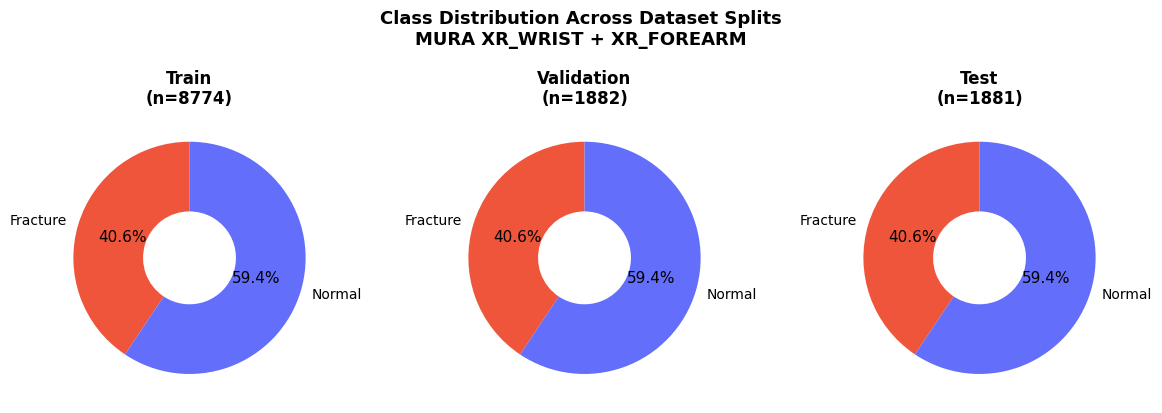

Fig. 1 saved


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

splits     = ['Train', 'Validation', 'Test']
totals     = [len(train_df), len(val_df), len(test_df)]
fractures  = [train_df.label.sum(), val_df.label.sum(), test_df.label.sum()]
normals    = [t - f for t, f in zip(totals, fractures)]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ['#EF553B', '#636EFA']

for ax, split, f, n in zip(axes, splits, fractures, normals):
    wedges, texts, autotexts = ax.pie(
        [f, n],
        labels=['Fracture', 'Normal'],
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.6)   # donut style
    )
    for autotext in autotexts:
        autotext.set_fontsize(11)
    ax.set_title(f'{split}\n(n={f+n})', fontsize=12, fontweight='bold')

plt.suptitle('Class Distribution Across Dataset Splits\nMURA XR_WRIST + XR_FOREARM',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig1_class_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Fig. 1 saved')

I0000 00:00:1776079461.712530      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


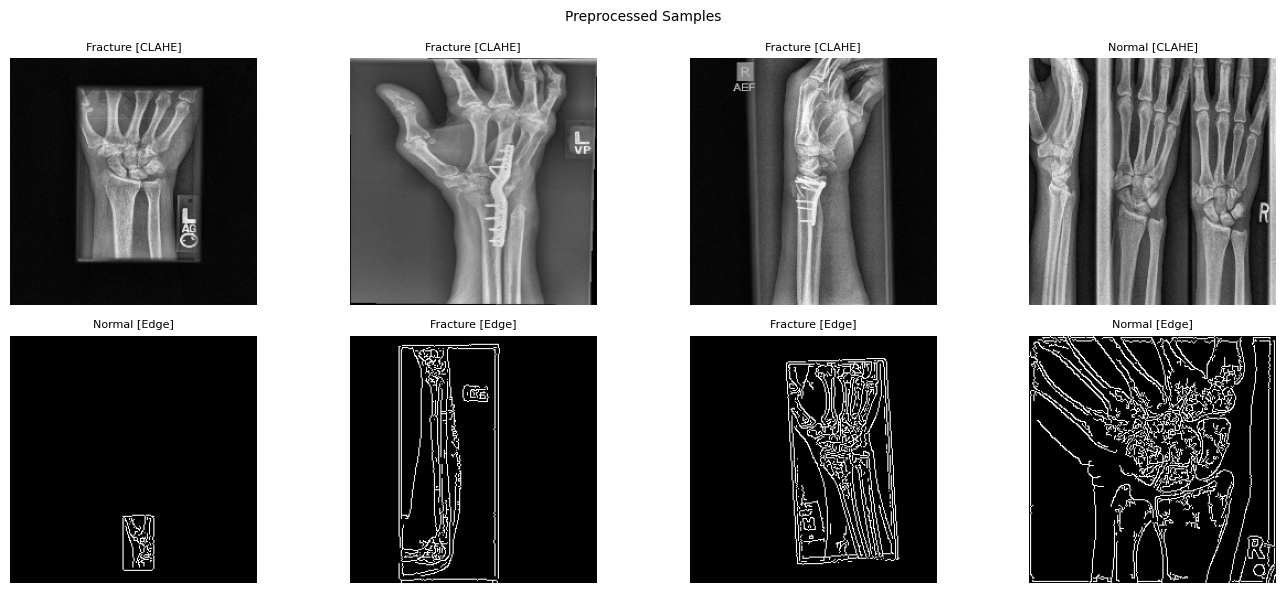

Preprocessing complete


In [3]:
if os.path.exists(CACHE_DIR): shutil.rmtree(CACHE_DIR)
os.makedirs(CACHE_DIR, exist_ok=True)

def preprocess_np(filepath, label):
    path  = filepath.decode('utf-8') if isinstance(filepath, bytes) else filepath
    img   = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32), np.int64(label)
    img   = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8)).apply(img)
    edges = cv2.Canny(clahe, 50, 150)
    stack = np.stack([clahe, edges, clahe], axis=-1).astype(np.float32) / 255.0
    return stack, np.int64(label)

def tf_preprocess(filepath, label):
    img, lbl = tf.numpy_function(preprocess_np, [filepath, label], [tf.float32, tf.int64])
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    lbl.set_shape([])
    return img, tf.cast(lbl, tf.float32)

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.07, 0.07),
    tf.keras.layers.RandomContrast(0.15),
], name='augmentation')

def make_dataset(df_in, augment=False, cache_name=None):
    ds = tf.data.Dataset.from_tensor_slices(
        (df_in['filepath'].values, df_in['label'].values.astype(np.int64)))
    ds = ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if cache_name:
        ds = ds.cache(os.path.join(CACHE_DIR, cache_name))
    if augment:
        ds = ds.map(lambda x, y: (
            tf.clip_by_value(augmentation(x, training=True), 0.0, 1.0), y),
            num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(512, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, augment=True,  cache_name='train')
val_ds   = make_dataset(val_df,   augment=False, cache_name='val')
test_ds  = make_dataset(test_df,  augment=False, cache_name='test')

# Quick visual check
vis_ds = make_dataset(train_df, augment=False, cache_name='vis')
sample_imgs, sample_labels = next(iter(vis_ds))
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ch = 1 if i >= 4 else 0
    ax.imshow(sample_imgs[i].numpy()[:, :, ch], cmap='gray')
    ax.set_title(f'{"Fracture" if sample_labels[i]==1 else "Normal"} [{"Edge" if ch else "CLAHE"}]', fontsize=8)
    ax.axis('off')
plt.suptitle('Preprocessed Samples', fontsize=10)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, 'samples.png'), dpi=100); plt.show()
del vis_ds; gc.collect()
print('Preprocessing complete')

## 4. LightFracNet Model (DenseNet121 + CBAM)

In [4]:
def cbam_block(x, ratio=8):
    channels = x.shape[-1]
    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(x)
    max_pool = tf.keras.layers.GlobalMaxPooling2D()(x)
    shared   = tf.keras.layers.Dense(channels // ratio, activation='relu', use_bias=False)
    ca = tf.keras.layers.Add()([shared(avg_pool), shared(max_pool)])
    ca = tf.keras.layers.Dense(channels, activation='sigmoid', use_bias=False)(ca)
    ca = tf.keras.layers.Reshape((1, 1, channels))(ca)
    x  = tf.keras.layers.Multiply()([x, ca])

    avg_sp = tf.keras.layers.Lambda(lambda t: __import__('tensorflow').reduce_mean(t, axis=-1, keepdims=True),output_shape=lambda s: (s[0], s[1], s[2], 1))(x)
    max_sp = tf.keras.layers.Lambda(lambda t: __import__('tensorflow').reduce_max(t,  axis=-1, keepdims=True),output_shape=lambda s: (s[0], s[1], s[2], 1))(x)
    sa = tf.keras.layers.Concatenate(axis=-1)([avg_sp, max_sp])
    sa = tf.keras.layers.Conv2D(1, 7, padding='same', activation='sigmoid', use_bias=False)(sa)
    x  = tf.keras.layers.Multiply()([x, sa])
    return x

def build_model():
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base   = tf.keras.applications.DenseNet121(
        include_top=False, weights='imagenet', input_tensor=inputs)

    for layer in base.layers[:100]: layer.trainable = False
    for layer in base.layers[100:]: layer.trainable = True

    x = base.output
    x = cbam_block(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    return tf.keras.Model(inputs, outputs, name='LightFracNet_v4')

model = build_model()
model.summary(line_length=90)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "LightFracNet_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1            │ (None, 224, 224, 3)  │            0 │ -                     │
│ (InputLayer)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ zero_padding2d           │ (None, 230, 230, 3)  │            0 │ input_layer_1[0][0]   │
│ (ZeroPadding2D)          │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1_conv (Conv2D)      │ (None, 112, 112, 64) │        9,408 │ zero_padding2d[0][0]  │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1_bn                 │ (None, 112, 112, 64) │          256 │ conv1_conv[0][0]      │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1_relu (Activation)  │ (None, 112, 112, 64) │            0 │ conv1_bn[0][0]        │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ zero_padding2d_1         │ (None, 114, 114, 64) │            0 │ conv1_relu[0][0]      │
│ (ZeroPadding2D)          │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ pool1 (MaxPooling2D)     │ (None, 56, 56, 64)   │            0 │ zero_padding2d_1[0][… │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_0_bn        │ (None, 56, 56, 64)   │          256 │ pool1[0][0]           │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_0_relu      │ (None, 56, 56, 64)   │            0 │ conv2_block1_0_bn[0]… │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_1_conv      │ (None, 56, 56, 128)  │        8,192 │ conv2_block1_0_relu[… │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_1_bn        │ (None, 56, 56, 128)  │          512 │ conv2_block1_1_conv[… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_1_relu      │ (None, 56, 56, 128)  │            0 │ conv2_block1_1_bn[0]… │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_2_conv      │ (None, 56, 56, 32)   │       36,864 │ conv2_block1_1_relu[… │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block1_concat      │ (None, 56, 56, 96)   │            0 │ pool1[0][0],          │
│ (Concatenate)            │                      │              │ conv2_block1_2_conv[… │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2_block2_0_bn        │ (None, 56, 56, 96)   │          384 │ conv2_block1_concat[… │
│ (BatchNormalization)     │                      │              │                     

 Total params: 7,582,755 (28.93 MB)

 Trainable params: 6,692,387 (25.53 MB)

 Non-trainable params: 890,368 (3.40 MB)

## 5. Training

In [5]:
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=train_df['label'].values)
class_weight_dict = {0: cw[0], 1: cw[1]}
print('Class weights:', class_weight_dict)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# Keras 3 safe LR scheduler — fixes AttributeError from older versions
def lr_schedule_fn(epoch):
    if epoch < 10: return float(INITIAL_LR)
    if epoch < 20: return float(INITIAL_LR * 0.5)
    if epoch < 35: return float(INITIAL_LR * 0.1)
    return float(MIN_LR)

class SafeLRScheduler(keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        new_lr = lr_schedule_fn(epoch)
        self.model.optimizer.learning_rate = new_lr
        print(f'  LR -> {new_lr:.2e}')

callbacks = [
    keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH, save_best_only=True, monitor='val_auc', mode='max', verbose=1),
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=10, restore_best_weights=True, mode='max', verbose=1),
    keras.callbacks.CSVLogger(CSV_LOG_PATH),
    SafeLRScheduler()
]

history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=TOTAL_EPOCHS, callbacks=callbacks,
    class_weight=class_weight_dict, verbose=1
)
print('Training complete!')

Class weights: {0: np.float64(0.8421961988865425), 1: np.float64(1.2305750350631135)}
  LR -> 2.00e-04
Epoch 1/50


I0000 00:00:1776079526.181310     130 service.cc:152] XLA service 0x7f3ab4006f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776079526.181361     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776079538.262817     130 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776079704.666025     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.6046 - auc: 0.6389 - loss: 0.6976 - precision: 0.5150 - recall: 0.6109
Epoch 1: val_auc improved from -inf to 0.79978, saving model to /kaggle/working/models/best_model_v4.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 567s 604ms/step - accuracy: 0.6047 - auc: 0.6390 - loss: 0.6975 - precision: 0.5150 - recall: 0.6110 - val_accuracy: 0.7396 - val_auc: 0.7998 - val_loss: 0.5477 - val_precision: 0.7200 - val_recall: 0.5882
  LR -> 2.00e-04
Epoch 2/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.7299 - auc: 0.7910 - loss: 0.5500 - precision: 0.6680 - recall: 0.6666
Epoch 2: val_auc improved from 0.79978 to 0.82922, saving model to /kaggle/working/models/best_model_v4.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 106s 183ms/step - accuracy: 0.7300 - auc: 0.7911 - loss: 0.5499 - precision: 0.6681 - recall: 0.6667 - val_accuracy: 0.7747 - val_auc: 0.8292 - val_loss: 0.4910 - val_precision: 0.8311 - val_recall: 0.5595
  LR -> 2.00e-04
Epoch 3/50
5

## 6. Training Curves

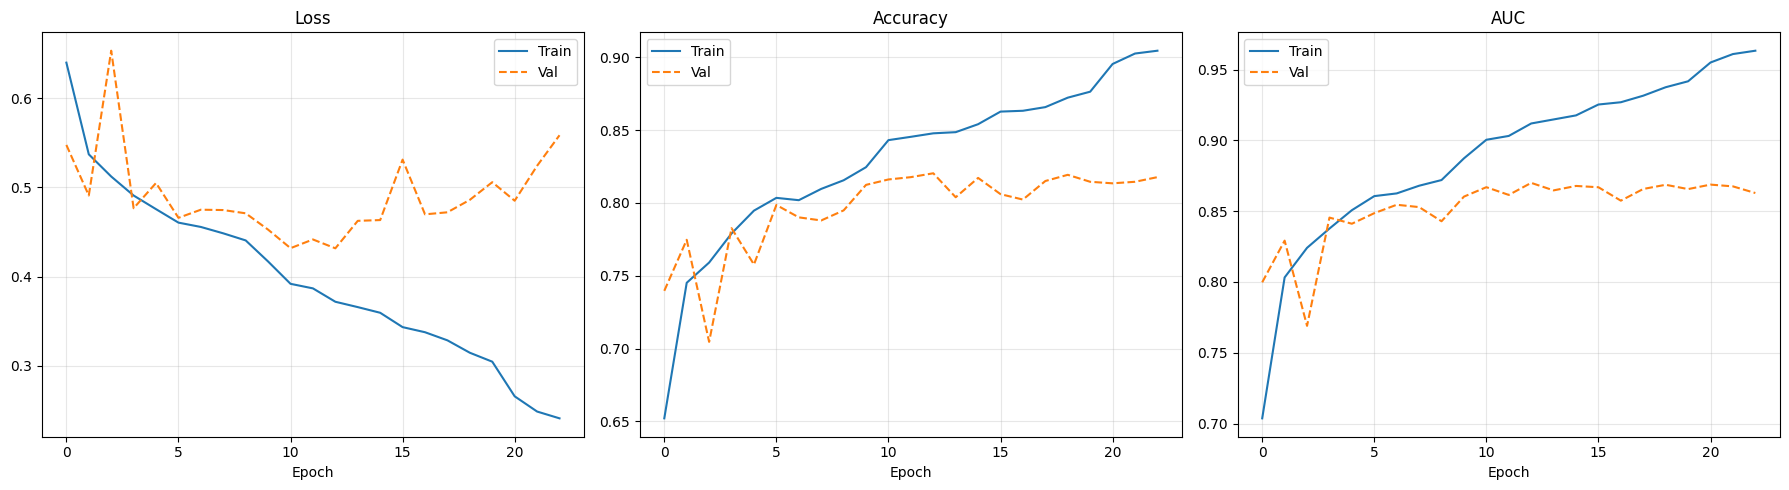

Best val_auc: 0.87


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (tr, va), title in zip(axes,
    [('loss','val_loss'),('accuracy','val_accuracy'),('auc','val_auc')],
    ['Loss','Accuracy','AUC']):
    ax.plot(history.history[tr],  label='Train')
    ax.plot(history.history[va], '--', label='Val')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150); plt.show()
print('Best val_auc:', round(max(history.history['val_auc']), 4))

## 7. Evaluation on Test Set


  Accuracy  : 0.8150
  ROC-AUC   : 0.8796
  F1-Score  : 0.7613
  Precision : 0.7997
  Recall    : 0.7264
              precision    recall  f1-score   support

      Normal       0.82      0.88      0.85      1117
    Fracture       0.80      0.73      0.76       764

    accuracy                           0.81      1881
   macro avg       0.81      0.80      0.81      1881
weighted avg       0.81      0.81      0.81      1881



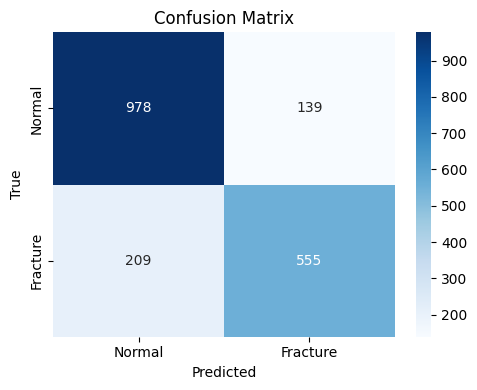

In [7]:
keras.config.enable_unsafe_deserialization()
best_model = tf.keras.models.load_model(
    CHECKPOINT_PATH,
    custom_objects={'tf': tf}
)

y_probs, y_true = [], []
for imgs, labels in test_ds:
    preds = best_model.predict(imgs, verbose=0)
    y_probs.extend(preds.flatten().tolist())
    y_true.extend(labels.numpy().tolist())

y_probs = np.array(y_probs)
y_true  = np.array(y_true)
y_pred  = (y_probs >= 0.5).astype(int)

acc  = accuracy_score(y_true, y_pred)
auc_ = roc_auc_score(y_true, y_probs)
f1   = f1_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)

print(f"\n{'='*40}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  ROC-AUC   : {auc_:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"{'='*40}")
print(classification_report(y_true, y_pred, target_names=['Normal','Fracture']))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fracture'], yticklabels=['Normal','Fracture'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=150); plt.show()

## 8. ROC Curve

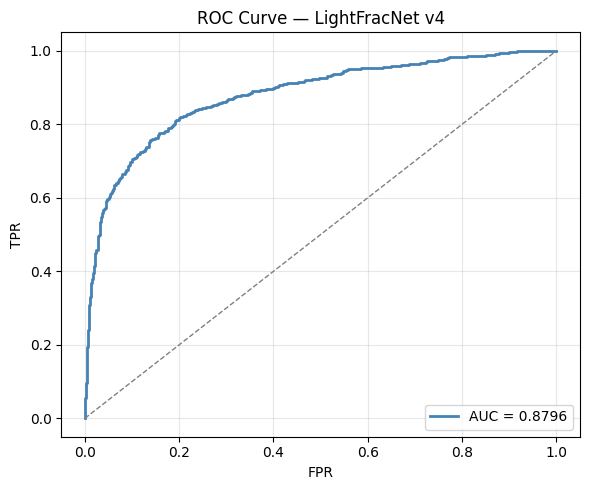

In [8]:
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc_val:.4f}')
plt.plot([0,1],[0,1],'--', color='gray', lw=1)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve — LightFracNet v4')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curve.png'), dpi=150); plt.show()

## 9. Grad-CAM Visualisation

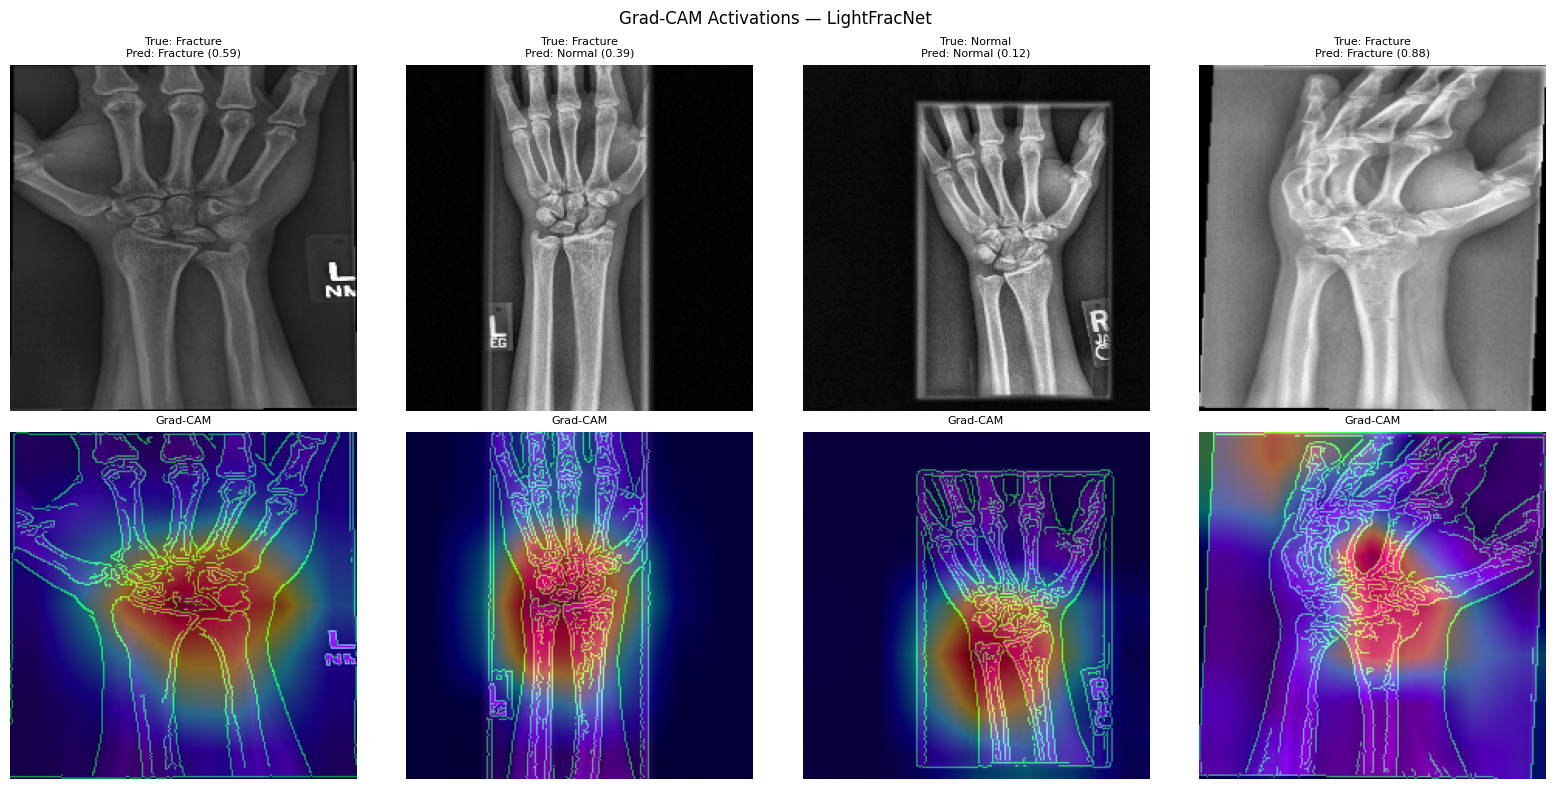

In [20]:
def make_gradcam_heatmap(img_array, model, last_conv='conv5_block16_2_conv'):
    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]
    grads   = tape.gradient(loss, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(1,2), keepdims=True)
    heatmap = tf.reduce_sum(tf.multiply(pooled, conv_out), axis=-1)[0]
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_np, heatmap, alpha=0.4):
    hm   = cv2.resize(heatmap.astype(np.float32), (img_np.shape[1], img_np.shape[0]))  # ← fix
    hm   = cv2.applyColorMap(np.uint8(255 * hm), cv2.COLORMAP_JET)
    base = np.uint8(img_np * 255)
    if base.ndim == 3 and base.shape[2] == 3:
        base = cv2.cvtColor(base, cv2.COLOR_RGB2BGR)
    sup  = cv2.addWeighted(base, 1 - alpha, hm, alpha, 0)
    return cv2.cvtColor(sup, cv2.COLOR_BGR2RGB)

sample_imgs_t, sample_labels_t = next(iter(test_ds))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    img        = sample_imgs_t[i:i+1]
    true_lbl   = int(sample_labels_t[i].numpy())
    pred_prob  = float(best_model.predict(img, verbose=0)[0][0])
    pred_lbl   = int(pred_prob >= 0.5)

    axes[0][i].imshow(img[0].numpy()[:, :, 0], cmap='gray')
    axes[0][i].set_title(
        f'True: {"Fracture" if true_lbl else "Normal"}\nPred: {"Fracture" if pred_lbl else "Normal"} ({pred_prob:.2f})',
        fontsize=8)
    axes[0][i].axis('off')

    heatmap  = make_gradcam_heatmap(img, best_model)
    overlaid = overlay_gradcam(img[0].numpy(), heatmap)
    axes[1][i].imshow(overlaid)
    axes[1][i].set_title('Grad-CAM', fontsize=8)
    axes[1][i].axis('off')

plt.suptitle('Grad-CAM Activations — LightFracNet ', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'gradcam.png'), dpi=150); plt.show()

## 10. Save Results Summary

In [10]:
summary = {
    'model': 'LightFracNet_v4',
    'backbone': 'DenseNet121 + CBAM',
    'body_parts': BODY_PARTS,
    'test_samples': int(len(y_true)),
    'accuracy':  round(float(acc),  4),
    'roc_auc':   round(float(auc_), 4),
    'f1_score':  round(float(f1),   4),
    'precision': round(float(prec), 4),
    'recall':    round(float(rec),  4),
}
with open(os.path.join(RESULTS_DIR, 'results_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))
print('\nOutputs saved in:', RESULTS_DIR)
print('Model saved at:  ', CHECKPOINT_PATH)

{
  "model": "LightFracNet_v4",
  "backbone": "DenseNet121 + CBAM",
  "body_parts": [
    "XR_WRIST",
    "XR_FOREARM"
  ],
  "test_samples": 1881,
  "accuracy": 0.815,
  "roc_auc": 0.8796,
  "f1_score": 0.7613,
  "precision": 0.7997,
  "recall": 0.7264
}

Outputs saved in: /kaggle/working/results
Model saved at:   /kaggle/working/models/best_model_v4.keras
